# Stream Data Analytics β€” Version 3

## Cardiac-cycle intelligence for SCG

Version 3 extends the causal Version 2 pipeline by explicitly detecting recurring heartbeats, segmenting complete cardiac cycles, phase-normalizing each beat, and learning from cycle timing, consistency, amplitude, and systolic/diastolic morphology.

The protocol remains unchanged:

- development uses only the first 20 minutes;
- one prediction is emitted after every completed second of the final 7 minutes;
- the four outputs are systolic pressure (`S`), diastolic pressure (`D`), heart rate (`H`), and respiratory rate (`R`);
- final score is $100-[MAE(S)+MAE(D)+MAE(H)+MAE(R)]$.

No final-stream label is used until every Version 3 prediction has been created.

## Scientific basis

- SCG records a recurring mechanical cardiac cycle with valve-related events such as mitral closure, aortic opening, aortic closure, and mitral opening. Sliding ensemble templates improve peak annotation under morphological variability and noise ([Shafiq et al., 2016](https://doi.org/10.1038/srep37524)).
- ECG-independent SCG beat timing can be recovered from adaptive envelopes and inter-beat intervals in real time ([Jafari Tadi et al., 2016](https://doi.org/10.1088/0967-3334/37/11/1885)).
- Normalized cross-correlation and templates containing systolic and diastolic complexes achieve accurate ECG-free heartbeat detection ([De Angelis et al., 2023](https://pubmed.ncbi.nlm.nih.gov/37430606/)).
- Ensemble-averaged SCG waves support separation of systolic and diastolic regions and estimation of heart rate ([Landreani et al., 2018](https://pmc.ncbi.nlm.nih.gov/articles/PMC6211127/)).
- The final model-selection procedure remains expanding-window validation to prevent training on the temporal future ([Bergmeir & BenΓ­tez, 2012](https://doi.org/10.1016/j.ins.2011.12.028)).

At each prediction time, the detector considers only the preceding 20 seconds. The Hilbert envelope is evaluated on that already-observed trailing window, so it introduces computation latency but no look-ahead beyond the prediction time.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy.signal import butter, find_peaks, hilbert, sosfilt, sosfilt_zi, sosfiltfilt
from scipy.stats import kurtosis, skew
from sklearn.base import clone
from sklearn.cross_decomposition import PLSRegression
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)

FS = 100
TRAIN_SECONDS = 20 * 60
STREAM_SECONDS = 7 * 60
TARGETS = list("SDHR")
RANDOM_STATE = 42
START = pd.Timestamp("2020-11-13 12:19:00")
DATA_DIR = Path(".")

## 1. Load and align the data

The sensor contains 1,620 complete 100 Hz seconds plus one incomplete sample. The 1,749 real label rows are irregularly spaced and are averaged into one-second bins. Missing labels remain missing and are reported explicitly.

In [2]:
started = perf_counter()

sensor_values = pd.read_csv(DATA_DIR / "sensor-27minutes.csv", usecols=["Value"])["Value"]
sensor_seconds = sensor_values.iloc[:-1].to_numpy(dtype=float).reshape(-1, FS) * 0.001

label_rows = pd.read_excel(
    DATA_DIR / "label-27minutes.xlsx",
    nrows=1749,
    usecols=["Calculated time", "S", "D", "H", "R"],
)
label_rows.index = pd.Timestamp("2020-11-13") + pd.to_timedelta(
    label_rows.pop("Calculated time").astype(str)
)

timeline = pd.date_range(START, periods=len(sensor_seconds), freq="1s")
targets = label_rows.resample("1s").mean().reindex(timeline)

data_audit = pd.DataFrame(
    {
        "partition": ["development", "final stream"],
        "sensor seconds": [TRAIN_SECONDS, STREAM_SECONDS],
        "seconds with all labels": [
            targets.iloc[:TRAIN_SECONDS].notna().all(axis=1).sum(),
            targets.iloc[TRAIN_SECONDS:].notna().all(axis=1).sum(),
        ],
        "seconds with missing labels": [
            targets.iloc[:TRAIN_SECONDS].isna().any(axis=1).sum(),
            targets.iloc[TRAIN_SECONDS:].isna().any(axis=1).sum(),
        ],
    }
)

display(data_audit)
print(f"Loaded and aligned in {perf_counter() - started:.2f} seconds")

,partition,sensor seconds,seconds with all labels,seconds with missing labels
0,development,1200,1156,44
1,final stream,420,398,22


Loaded and aligned in 0.45 seconds


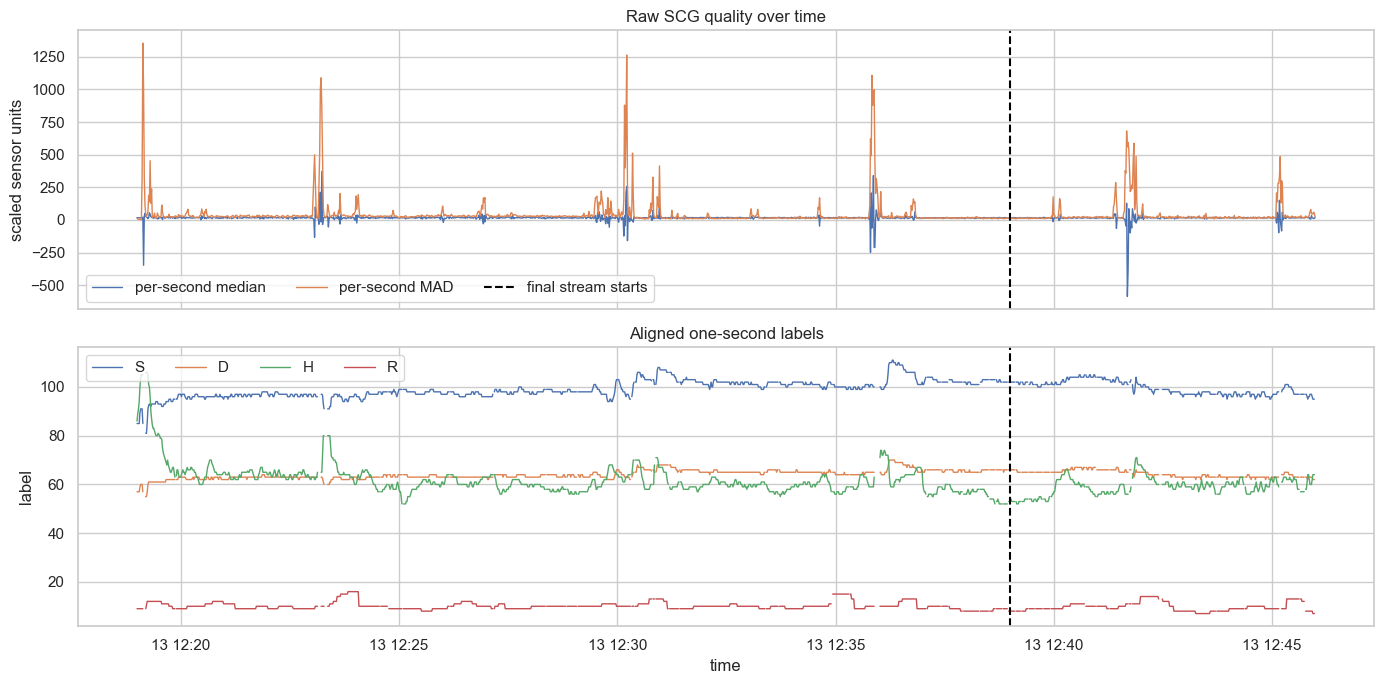

In [3]:
sensor_median = np.median(sensor_seconds, axis=1)
sensor_mad = np.median(np.abs(sensor_seconds - sensor_median[:, None]), axis=1)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
axes[0].plot(timeline, sensor_median, label="per-second median", linewidth=1)
axes[0].plot(timeline, sensor_mad, label="per-second MAD", linewidth=1)
axes[0].axvline(timeline[TRAIN_SECONDS], color="black", linestyle="--", label="final stream starts")
axes[0].set(title="Raw SCG quality over time", ylabel="scaled sensor units")
axes[0].legend(ncol=3)

for target in TARGETS:
    axes[1].plot(targets.index, targets[target], label=target, linewidth=1)
axes[1].axvline(timeline[TRAIN_SECONDS], color="black", linestyle="--")
axes[1].set(title="Aligned one-second labels", xlabel="time", ylabel="label")
axes[1].legend(ncol=4)
plt.tight_layout();

## 2. Version 2 signal features

The causal Version 2 feature extractor is retained as the non-cycle baseline. It learns clipping thresholds only from development samples and produces robust amplitude, cardiac-band, morphology-band, spectral, peak, and trailing multiscale features without clock time.

In [4]:
class SCGFeatureExtractor:
    def __init__(self, sample_rate=100, clip_mad=8, rolling_windows=(5, 15, 30, 60)):
        self.sample_rate = sample_rate
        self.clip_mad = clip_mad
        self.rolling_windows = rolling_windows

    def fit(self, seconds):
        values = np.asarray(seconds).ravel()
        self.center_ = np.median(values)
        self.scale_ = 1.4826 * np.median(np.abs(values - self.center_))
        return self

    def _bandpass(self, values, low, high):
        sos = butter(
            4,
            [low, high],
            btype="bandpass",
            fs=self.sample_rate,
            output="sos",
        )
        initial_state = sosfilt_zi(sos) * values[0]
        return sosfilt(sos, values, zi=initial_state)[0]

    def _statistics(self, name, values, output):
        quantiles = np.quantile(values, [0.10, 0.25, 0.50, 0.75, 0.90], axis=1)
        median = quantiles[2]
        output[f"{name}_mean"] = values.mean(axis=1)
        output[f"{name}_std"] = values.std(axis=1)
        output[f"{name}_median"] = median
        output[f"{name}_mad"] = np.median(np.abs(values - median[:, None]), axis=1)
        output[f"{name}_iqr"] = quantiles[3] - quantiles[1]
        output[f"{name}_q90_q10"] = quantiles[4] - quantiles[0]
        output[f"{name}_rms"] = np.sqrt(np.mean(values**2, axis=1))
        output[f"{name}_line_length"] = np.mean(np.abs(np.diff(values, axis=1)), axis=1)
        output[f"{name}_zcr"] = np.mean(
            np.diff(np.signbit(values - median[:, None]), axis=1), axis=1
        )
        output[f"{name}_skew"] = skew(values, axis=1, bias=False)
        output[f"{name}_kurtosis"] = kurtosis(values, axis=1, bias=False)

    def _spectral_features(self, name, values, output):
        frequencies = np.fft.rfftfreq(self.sample_rate, 1 / self.sample_rate)
        centered = values - values.mean(axis=1, keepdims=True)
        power = np.abs(np.fft.rfft(centered, axis=1)) ** 2
        total_power = power[:, 1:].sum(axis=1) + 1e-12

        for low, high in [(1, 2), (2, 4), (4, 8), (8, 15), (15, 30)]:
            band = (frequencies >= low) & (frequencies < high)
            band_power = power[:, band].sum(axis=1)
            output[f"{name}_logpower_{low}_{high}"] = np.log1p(band_power)
            output[f"{name}_relpower_{low}_{high}"] = band_power / total_power

        band = (frequencies >= 1) & (frequencies <= 30)
        output[f"{name}_dominant_hz"] = frequencies[band][
            np.argmax(power[:, band], axis=1)
        ]
        probabilities = power[:, band] / (power[:, band].sum(axis=1, keepdims=True) + 1e-12)
        output[f"{name}_spectral_entropy"] = -(
            probabilities * np.log(probabilities + 1e-12)
        ).sum(axis=1) / np.log(probabilities.shape[1])

    def _peak_features(self, morphology):
        counts, prominences, intervals = [], [], []
        for second in morphology:
            peaks, properties = find_peaks(
                np.abs(second),
                distance=18,
                prominence=np.std(second) * 0.35,
            )
            counts.append(len(peaks))
            prominences.append(np.median(properties["prominences"]) if len(peaks) else 0)
            intervals.append(
                np.median(np.diff(peaks)) / self.sample_rate if len(peaks) > 1 else 0
            )
        return counts, prominences, intervals

    def _heart_rate_features(self, heart_signal):
        fft_rates, autocorrelation_rates = [], []
        flattened = heart_signal.ravel()

        for second_index in range(len(heart_signal)):
            start = max(0, (second_index + 1 - 10) * self.sample_rate)
            values = flattened[start : (second_index + 1) * self.sample_rate]
            values = values - values.mean()
            frequencies = np.fft.rfftfreq(len(values), 1 / self.sample_rate)
            power = np.abs(np.fft.rfft(values)) ** 2
            heart_band = (frequencies >= 0.65) & (frequencies <= 2.5)
            fft_rates.append(
                frequencies[heart_band][np.argmax(power[heart_band])] * 60
            )

            autocorrelation = np.correlate(values, values, mode="full")[len(values) - 1 :]
            autocorrelation = autocorrelation / (autocorrelation[0] + 1e-12)
            low_lag = int(self.sample_rate / 2.5)
            high_lag = int(self.sample_rate / 0.65)
            peaks, _ = find_peaks(autocorrelation[low_lag : high_lag + 1])
            if len(peaks):
                lag = low_lag + peaks[
                    np.argmax(autocorrelation[low_lag + peaks])
                ]
            else:
                lag = low_lag + np.argmax(
                    autocorrelation[low_lag : high_lag + 1]
                )
            autocorrelation_rates.append(60 * self.sample_rate / lag)

        return fft_rates, autocorrelation_rates

    def _respiratory_rate(self, values):
        rates = []
        for second_index in range(len(values)):
            window = values[max(0, second_index + 1 - 60) : second_index + 1]
            window = window - window.mean()
            if len(window) < 10:
                rates.append(12.0)
                continue
            frequencies = np.fft.rfftfreq(len(window), 1.0)
            power = np.abs(np.fft.rfft(window)) ** 2
            respiratory_band = (frequencies >= 0.10) & (frequencies <= 0.40)
            rates.append(
                frequencies[respiratory_band][
                    np.argmax(power[respiratory_band])
                ]
                * 60
            )
        return rates

    def transform(self, seconds):
        raw = np.asarray(seconds)
        low = self.center_ - self.clip_mad * self.scale_
        high = self.center_ + self.clip_mad * self.scale_
        clean_flat = np.clip(raw.ravel(), low, high)
        clean = clean_flat.reshape(-1, self.sample_rate)
        heart = self._bandpass(clean_flat, 0.7, 4.0).reshape(-1, self.sample_rate)
        morphology = self._bandpass(clean_flat, 4.0, 30.0).reshape(-1, self.sample_rate)

        output = {}
        for name, values in [("clean", clean), ("heart", heart), ("morph", morphology)]:
            self._statistics(name, values, output)
            self._spectral_features(name, values, output)

        output["artifact_fraction"] = np.mean((raw < low) | (raw > high), axis=1)
        output["raw_median"] = np.median(raw, axis=1)
        output["raw_mad"] = np.median(
            np.abs(raw - np.median(raw, axis=1)[:, None]), axis=1
        )
        (
            output["peak_count"],
            output["peak_prominence"],
            output["peak_interval"],
        ) = self._peak_features(morphology)

        features = pd.DataFrame(output)
        rolling_columns = [
            "clean_median",
            "clean_mad",
            "clean_rms",
            "clean_line_length",
            "heart_rms",
            "heart_line_length",
            "morph_rms",
            "morph_line_length",
            "morph_logpower_4_8",
            "morph_logpower_8_15",
            "heart_logpower_1_2",
            "heart_logpower_2_4",
            "peak_count",
            "peak_prominence",
            "artifact_fraction",
        ]

        for window in self.rolling_windows:
            rolling = features[rolling_columns].rolling(window, min_periods=1)
            features = pd.concat(
                [
                    features,
                    rolling.mean().add_suffix(f"_mean_{window}s"),
                    rolling.std(ddof=0).add_suffix(f"_std_{window}s"),
                ],
                axis=1,
            )

        (
            features["heart_rate_fft"],
            features["heart_rate_autocorr"],
        ) = self._heart_rate_features(heart)
        features["morph_rms_resp_rate"] = self._respiratory_rate(
            features["morph_rms"].to_numpy()
        )
        features["clean_median_resp_rate"] = self._respiratory_rate(
            features["clean_median"].to_numpy()
        )
        features.index = timeline[: len(features)]
        return features


feature_extractor = SCGFeatureExtractor(sample_rate=FS).fit(
    sensor_seconds[:TRAIN_SECONDS]
)
feature_started = perf_counter()
features = feature_extractor.transform(sensor_seconds)

print(f"Created {features.shape[1]} causal features for {features.shape[0]} seconds")
print(f"Feature extraction time: {perf_counter() - feature_started:.2f} seconds")
print("Clock-derived features:", [name for name in features if name in {"minute", "second", "elapsed_seconds"}])

Created 199 causal features for 1620 seconds
Feature extraction time: 0.78 seconds
Clock-derived features: []


## 3. Detect and phase-normalize cardiac cycles

The cycle detector uses a causal 4β€“30 Hz morphology signal and a smoothed Hilbert amplitude envelope over the preceding 20 seconds. Envelope peaks are separated by at least 450 ms, allowing rates up to about 133 bpm. Consecutive peak intervals between 450 ms and 1.5 s define complete candidate cycles.

Every accepted cycle is interpolated onto 32 phase positions. A robust median template and amplitude-normalized template summarize the recurring waveform. The resulting features include inter-beat timing, direct cycle HR, rate variability, peak prominence, beat consistency, amplitude, normalized morphology, and separate first-half/second-half energy and range as systolic/diastolic proxies.

In [5]:
class CardiacCycleFeatureExtractor:
    def __init__(
        self,
        sample_rate=100,
        window_seconds=20,
        phase_bins=32,
        minimum_peak_distance=0.45,
        envelope_cutoff=1.5,
        prominence_fraction=0.15,
    ):
        self.sample_rate = sample_rate
        self.window_seconds = window_seconds
        self.phase_bins = phase_bins
        self.minimum_peak_distance = minimum_peak_distance
        self.envelope_cutoff = envelope_cutoff
        self.prominence_fraction = prominence_fraction

    def fit(self, seconds):
        values = np.asarray(seconds).ravel()
        self.center_ = np.median(values)
        self.scale_ = 1.4826 * np.median(np.abs(values - self.center_))
        return self

    def _morphology_signal(self, seconds):
        values = np.asarray(seconds).ravel()
        values = np.clip(
            values,
            self.center_ - 8 * self.scale_,
            self.center_ + 8 * self.scale_,
        )
        sos = butter(
            4,
            [4, 30],
            btype="bandpass",
            fs=self.sample_rate,
            output="sos",
        )
        initial_state = sosfilt_zi(sos) * values[0]
        return values, sosfilt(sos, values, zi=initial_state)[0]

    def _window_cycles(self, morphology, end_sample):
        start_sample = max(
            0, end_sample - self.window_seconds * self.sample_rate
        )
        window = morphology[start_sample:end_sample]
        envelope_sos = butter(
            3,
            self.envelope_cutoff,
            btype="lowpass",
            fs=self.sample_rate,
            output="sos",
        )
        envelope = sosfiltfilt(envelope_sos, np.abs(hilbert(window)))
        boundary = min(self.sample_rate, len(window) // 10)
        peaks, properties = find_peaks(
            envelope,
            distance=int(self.minimum_peak_distance * self.sample_rate),
            prominence=np.std(envelope) * self.prominence_fraction,
        )
        keep = (peaks >= boundary) & (peaks < len(window) - 10)
        peaks = peaks[keep]
        prominences = properties["prominences"][keep]
        intervals = np.diff(peaks) / self.sample_rate
        valid_intervals = (intervals >= 0.45) & (intervals <= 1.5)

        cycles = []
        for cycle_number, valid in enumerate(valid_intervals):
            if valid:
                waveform = window[peaks[cycle_number] : peaks[cycle_number + 1]]
                phase = np.linspace(0, len(waveform) - 1, self.phase_bins)
                cycles.append(
                    np.interp(phase, np.arange(len(waveform)), waveform)
                )

        return {
            "start_sample": start_sample,
            "window": window,
            "envelope": envelope,
            "peaks": peaks,
            "prominences": prominences,
            "intervals": intervals,
            "valid_intervals": valid_intervals,
            "cycles": cycles,
        }

    def _cycle_row(self, detected, artifact_fraction):
        intervals = detected["intervals"]
        valid_intervals = detected["valid_intervals"]
        cycles = detected["cycles"]
        prominences = detected["prominences"]
        row = {
            "cycle_detected": float(bool(cycles)),
            "cycle_count": len(cycles),
            "anchor_count": len(detected["peaks"]),
            "interval_valid_fraction": (
                valid_intervals.mean() if len(valid_intervals) else 0
            ),
            "envelope_prominence_median": (
                np.median(prominences) if len(prominences) else 0
            ),
            "window_artifact_fraction": artifact_fraction,
        }
        if not cycles:
            return row

        intervals = intervals[valid_intervals]
        cycle_matrix = np.asarray(cycles)
        template = np.median(cycle_matrix, axis=0)
        normalized_cycles = (
            cycle_matrix - cycle_matrix.mean(axis=1, keepdims=True)
        ) / (cycle_matrix.std(axis=1, keepdims=True) + 1e-12)
        normalized_template = np.median(normalized_cycles, axis=0)
        consistency = np.mean(
            normalized_cycles * normalized_template, axis=1
        ) / (np.std(normalized_template) + 1e-12)
        amplitudes = np.ptp(cycle_matrix, axis=1)
        half = self.phase_bins // 2

        row.update(
            {
                "interval_median": np.median(intervals),
                "interval_mean": intervals.mean(),
                "interval_std": intervals.std(),
                "interval_iqr": np.subtract(
                    *np.quantile(intervals, [0.75, 0.25])
                ),
                "cycle_hr": 60 / np.median(intervals),
                "cycle_hr_mean": np.mean(60 / intervals),
                "cycle_hr_std": np.std(60 / intervals),
                "cycle_amplitude_median": np.median(amplitudes),
                "cycle_amplitude_std": amplitudes.std(),
                "cycle_consistency": np.median(consistency),
                "template_range": np.ptp(template),
                "template_rms": np.sqrt(np.mean(template**2)),
                "template_line_length": np.mean(np.abs(np.diff(template))),
                "template_max_phase": np.argmax(template) / (self.phase_bins - 1),
                "template_min_phase": np.argmin(template) / (self.phase_bins - 1),
                "template_skew": skew(template),
                "template_kurtosis": kurtosis(template),
                "systolic_energy": np.mean(template[:half] ** 2),
                "diastolic_energy": np.mean(template[half:] ** 2),
                "systolic_range": np.ptp(template[:half]),
                "diastolic_range": np.ptp(template[half:]),
            }
        )
        for phase in range(0, self.phase_bins, 2):
            row[f"template_{phase:02d}"] = template[phase]
            row[f"normalized_template_{phase:02d}"] = normalized_template[phase]
        return row

    def transform(self, seconds):
        raw = np.asarray(seconds)
        clean, morphology = self._morphology_signal(raw)
        self.morphology_ = morphology
        low = self.center_ - 8 * self.scale_
        high = self.center_ + 8 * self.scale_
        rows = []

        for second_number in range(len(raw)):
            end_sample = (second_number + 1) * self.sample_rate
            detected = self._window_cycles(morphology, end_sample)
            raw_window = raw.ravel()[detected["start_sample"] : end_sample]
            artifact_fraction = np.mean((raw_window < low) | (raw_window > high))
            rows.append(self._cycle_row(detected, artifact_fraction))

        features = pd.DataFrame(rows).ffill().fillna(0)
        age = 0
        cycle_age = []
        for detected in features["cycle_detected"]:
            age = 0 if detected else age + 1
            cycle_age.append(age)
        features["cycle_age"] = cycle_age
        features["cycle_hr_ewm"] = features["cycle_hr"].ewm(
            alpha=0.2, adjust=False
        ).mean()
        features.index = timeline[: len(features)]
        return features

    def diagnostic_window(self, end_second):
        return self._window_cycles(
            self.morphology_, end_second * self.sample_rate
        )


cycle_started = perf_counter()
cycle_extractor = CardiacCycleFeatureExtractor(sample_rate=FS).fit(
    sensor_seconds[:TRAIN_SECONDS]
)
cycle_features = cycle_extractor.transform(sensor_seconds)
combined_features = pd.concat(
    [features, cycle_features.add_prefix("cycle__")], axis=1
)

print(f"Created {cycle_features.shape[1]} explicit cardiac-cycle features")
print(f"Combined feature count: {combined_features.shape[1]}")
print(f"Cycle extraction time: {perf_counter() - cycle_started:.2f} seconds")

Created 61 explicit cardiac-cycle features
Combined feature count: 260
Cycle extraction time: 4.85 seconds


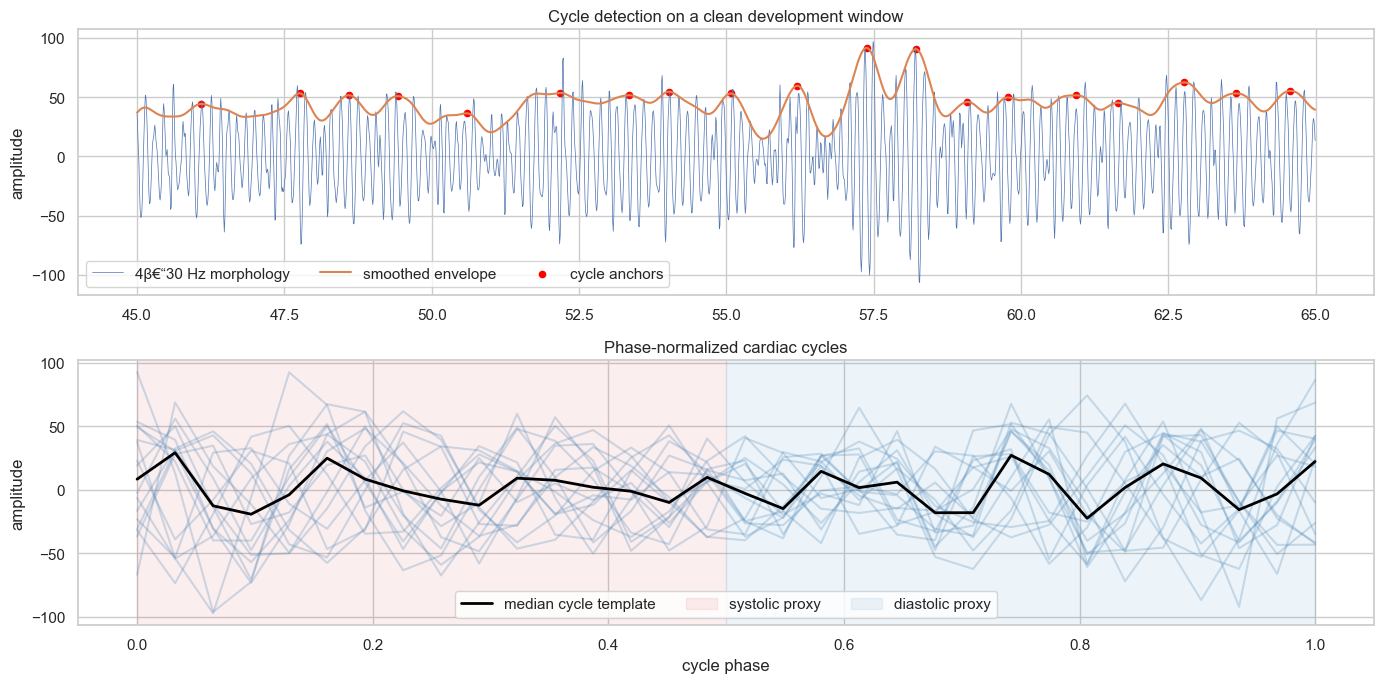

In [6]:
diagnostic = cycle_extractor.diagnostic_window(end_second=65)
window_time = (
    np.arange(len(diagnostic["window"])) + diagnostic["start_sample"]
) / FS

fig, axes = plt.subplots(2, 1, figsize=(14, 7))
axes[0].plot(window_time, diagnostic["window"], linewidth=0.5, label="4β€“30 Hz morphology")
axes[0].plot(window_time, diagnostic["envelope"], linewidth=1.5, label="smoothed envelope")
axes[0].scatter(
    window_time[diagnostic["peaks"]],
    diagnostic["envelope"][diagnostic["peaks"]],
    color="red",
    s=20,
    label="cycle anchors",
)
axes[0].set(title="Cycle detection on a clean development window", ylabel="amplitude")
axes[0].legend(ncol=3)

for cycle in diagnostic["cycles"]:
    axes[1].plot(np.linspace(0, 1, len(cycle)), cycle, color="steelblue", alpha=0.25)
axes[1].plot(
    np.linspace(0, 1, cycle_extractor.phase_bins),
    np.median(np.asarray(diagnostic["cycles"]), axis=0),
    color="black",
    linewidth=2,
    label="median cycle template",
)
axes[1].axvspan(0, 0.5, color="tab:red", alpha=0.08, label="systolic proxy")
axes[1].axvspan(0.5, 1, color="tab:blue", alpha=0.08, label="diastolic proxy")
axes[1].set(title="Phase-normalized cardiac cycles", xlabel="cycle phase", ylabel="amplitude")
axes[1].legend(ncol=3)
plt.tight_layout();

## 4. Expanding-window, target-specific model selection

The physiology and noise mechanisms differ by target, so Version 3 permits a different training-only winner for each output. Candidate representations are Version 2 features alone, cycle features alone, or both together. Ridge, PLS, and Extra Trees are compared across the same three forward 200-second validation blocks used in Version 2.

For `H`, the direct cycle rate $60/\mathrm{median}(IBI)$ is also an eligible scientific estimator. It contains no label-fitted coefficients and is evaluated in exactly the same validation windows.

In [7]:
valid_development = targets.iloc[:TRAIN_SECONDS].notna().all(axis=1).to_numpy()
development_second_numbers = np.flatnonzero(valid_development)
y_development = targets.iloc[:TRAIN_SECONDS].loc[valid_development].reset_index(drop=True)

feature_sets = {
    "base": features.iloc[:TRAIN_SECONDS].loc[valid_development].reset_index(drop=True),
    "cycle": cycle_features.iloc[:TRAIN_SECONDS].loc[valid_development].reset_index(drop=True),
    "combined": combined_features.iloc[:TRAIN_SECONDS].loc[valid_development].reset_index(drop=True),
}
full_feature_sets = {
    "base": features,
    "cycle": cycle_features,
    "combined": combined_features,
}

folds = [
    (
        np.flatnonzero(development_second_numbers < fold_end - 200),
        np.flatnonzero(
            (development_second_numbers >= fold_end - 200)
            & (development_second_numbers < fold_end)
        ),
    )
    for fold_end in [800, 1000, 1200]
]

model_specs = {
    "Base Ridge 30": ("base", make_pipeline(StandardScaler(), Ridge(alpha=30))),
    "Base Ridge 100": ("base", make_pipeline(StandardScaler(), Ridge(alpha=100))),
    "Base Ridge 300": ("base", make_pipeline(StandardScaler(), Ridge(alpha=300))),
    "Cycle Ridge 10": ("cycle", make_pipeline(StandardScaler(), Ridge(alpha=10))),
    "Cycle Ridge 30": ("cycle", make_pipeline(StandardScaler(), Ridge(alpha=30))),
    "Cycle Ridge 100": ("cycle", make_pipeline(StandardScaler(), Ridge(alpha=100))),
    "Combined Ridge 30": ("combined", make_pipeline(StandardScaler(), Ridge(alpha=30))),
    "Combined Ridge 100": ("combined", make_pipeline(StandardScaler(), Ridge(alpha=100))),
    "Combined Ridge 300": ("combined", make_pipeline(StandardScaler(), Ridge(alpha=300))),
    "Combined PLS 8": ("combined", PLSRegression(n_components=8, scale=True, max_iter=1000)),
    "Combined Extra Trees": (
        "combined",
        ExtraTreesRegressor(
            n_estimators=300,
            min_samples_leaf=5,
            max_features=0.7,
            n_jobs=-1,
            random_state=RANDOM_STATE,
        ),
    ),
}

validation_rows = []
selection_started = perf_counter()
for model_number, (name, (feature_set_name, model)) in enumerate(
    model_specs.items(), start=1
):
    X = feature_sets[feature_set_name]
    fold_maes = []
    for train_rows, validation_rows_index in folds:
        fitted = clone(model).fit(X.iloc[train_rows], y_development.iloc[train_rows])
        fold_maes.append(
            mean_absolute_error(
                y_development.iloc[validation_rows_index],
                fitted.predict(X.iloc[validation_rows_index]),
                multioutput="raw_values",
            )
        )
    mean_mae = np.mean(fold_maes, axis=0)
    validation_rows.append(
        {
            "model": name,
            "feature set": feature_set_name,
            **dict(zip(TARGETS, mean_mae)),
            "sum MAE": mean_mae.sum(),
            "score": 100 - mean_mae.sum(),
        }
    )
    elapsed = perf_counter() - selection_started
    remaining = elapsed / model_number * (len(model_specs) - model_number)
    print(
        f"{model_number:2d}/{len(model_specs)} {name}: "
        f"score={100 - mean_mae.sum():.3f}; elapsed={elapsed:.1f}s; ETA={remaining:.1f}s"
    )

direct_cycle_maes = []
for _, validation_rows_index in folds:
    direct_cycle_maes.append(
        mean_absolute_error(
            y_development.iloc[validation_rows_index]["H"],
            feature_sets["cycle"].iloc[validation_rows_index]["cycle_hr"],
        )
    )
validation_rows.append(
    {
        "model": "Direct cardiac-cycle rate",
        "feature set": "cycle",
        "S": np.nan,
        "D": np.nan,
        "H": np.mean(direct_cycle_maes),
        "R": np.nan,
        "sum MAE": np.nan,
        "score": np.nan,
    }
)

validation_results = pd.DataFrame(validation_rows)
display(validation_results.sort_values("sum MAE").round(3))

selected_by_target = {}
for target in TARGETS:
    eligible = validation_results.dropna(subset=[target])
    selected_by_target[target] = eligible.loc[eligible[target].idxmin(), "model"]

selection_summary = pd.DataFrame(
    {
        "selected model": pd.Series(selected_by_target),
        "validation MAE": [
            validation_results.loc[
                validation_results["model"] == selected_by_target[target], target
            ].iloc[0]
            for target in TARGETS
        ],
    }
)
display(selection_summary.round(3))
print(
    "Target-specific validation score:",
    round(100 - selection_summary["validation MAE"].sum(), 3),
)

 1/11 Base Ridge 30: score=89.754; elapsed=0.0s; ETA=0.5s
 2/11 Base Ridge 100: score=90.078; elapsed=0.1s; ETA=0.5s
 3/11 Base Ridge 300: score=89.998; elapsed=0.1s; ETA=0.4s
 4/11 Cycle Ridge 10: score=89.353; elapsed=0.2s; ETA=0.3s
 5/11 Cycle Ridge 30: score=89.359; elapsed=0.2s; ETA=0.2s
 6/11 Cycle Ridge 100: score=89.352; elapsed=0.2s; ETA=0.2s


 7/11 Combined Ridge 30: score=89.943; elapsed=0.3s; ETA=0.2s
 8/11 Combined Ridge 100: score=90.194; elapsed=0.3s; ETA=0.1s
 9/11 Combined Ridge 300: score=90.052; elapsed=0.4s; ETA=0.1s
10/11 Combined PLS 8: score=89.722; elapsed=0.5s; ETA=0.0s


11/11 Combined Extra Trees: score=89.198; elapsed=3.3s; ETA=0.0s


,model,feature set,S,D,H,R,sum MAE,score
7,Combined Ridge 100,combined,3.367,1.814,3.177,1.448,9.806,90.194
1,Base Ridge 100,base,3.143,1.695,3.733,1.351,9.922,90.078
8,Combined Ridge 300,combined,3.428,1.790,3.354,1.376,9.948,90.052
2,Base Ridge 300,base,3.290,1.711,3.721,1.279,10.002,89.998
6,Combined Ridge 30,combined,3.434,1.890,3.239,1.494,10.057,89.943
0,Base Ridge 30,base,3.134,1.738,3.952,1.422,10.246,89.754
9,Combined PLS 8,combined,3.545,1.790,3.533,1.411,10.278,89.722
4,Cycle Ridge 30,cycle,4.028,2.027,2.931,1.656,10.641,89.359
3,Cycle Ridge 10,cycle,3.899,1.968,2.929,1.850,10.647,89.353
5,Cycle Ridge 100,cycle,4.100,2.059,3.048,1.440,10.648,89.352


,selected model,validation MAE
S,Base Ridge 30,3.134
D,Base Ridge 100,1.695
H,Direct cardiac-cycle rate,2.325
R,Combined Extra Trees,1.105


Target-specific validation score: 91.741


## 5. Fit selected models and simulate the final stream

Each selected supervised model is fitted on all available development labels. During the final stream, a model receives only the causal feature row available after that second. If the direct cardiac-cycle rate wins for `H`, no learned label or future observation is involved in its stream estimate.

In [8]:
fitted_models = {}
for model_name in set(selected_by_target.values()):
    if model_name == "Direct cardiac-cycle rate":
        continue
    feature_set_name, model = model_specs[model_name]
    fitted_models[model_name] = clone(model).fit(
        feature_sets[feature_set_name], y_development
    )

stream_predictions = []
stream_started = perf_counter()

for completed, second_number in enumerate(
    range(TRAIN_SECONDS, TRAIN_SECONDS + STREAM_SECONDS), start=1
):
    model_outputs = {}
    prediction = {}
    for target_number, target in enumerate(TARGETS):
        model_name = selected_by_target[target]
        if model_name == "Direct cardiac-cycle rate":
            prediction[target] = cycle_features.iloc[second_number]["cycle_hr"]
            continue
        if model_name not in model_outputs:
            feature_set_name = model_specs[model_name][0]
            model_outputs[model_name] = fitted_models[model_name].predict(
                full_feature_sets[feature_set_name].iloc[[second_number]]
            )[0]
        prediction[target] = model_outputs[model_name][target_number]
    stream_predictions.append(prediction)

    if completed % 60 == 0 or completed == STREAM_SECONDS:
        elapsed = perf_counter() - stream_started
        remaining = elapsed / completed * (STREAM_SECONDS - completed)
        print(
            f"Predicted {completed:3d}/{STREAM_SECONDS} seconds; "
            f"elapsed={elapsed:.2f}s; ETA={remaining:.2f}s"
        )

predictions = pd.DataFrame(stream_predictions, index=timeline[TRAIN_SECONDS:])
print(f"All Version 3 stream predictions completed in {perf_counter() - stream_started:.2f} seconds")
display(predictions.head())

Predicted  60/420 seconds; elapsed=3.46s; ETA=20.78s


Predicted 120/420 seconds; elapsed=6.75s; ETA=16.86s


Predicted 180/420 seconds; elapsed=10.24s; ETA=13.66s


Predicted 240/420 seconds; elapsed=13.52s; ETA=10.14s


Predicted 300/420 seconds; elapsed=16.86s; ETA=6.74s


Predicted 360/420 seconds; elapsed=20.27s; ETA=3.38s


Predicted 420/420 seconds; elapsed=23.62s; ETA=0.00s
All Version 3 stream predictions completed in 23.62 seconds


,S,D,H,R
2020-11-13 12:39:00,101.944407,65.337239,52.631579,8.702544
2020-11-13 12:39:01,102.230955,65.670778,51.724138,8.669032
2020-11-13 12:39:02,102.787143,65.898292,52.173913,8.694582
2020-11-13 12:39:03,102.330331,65.528165,53.097345,8.704901
2020-11-13 12:39:04,102.511266,65.665485,53.097345,8.663557


## 6. Final holdout evaluation

The final labels are accessed only after stream prediction. All four targets are scored on the same 398 seconds having complete references; the remaining 22 seconds are reported as unavailable rather than silently swallowed.

In [9]:
stream_targets = targets.iloc[TRAIN_SECONDS:]
scored_seconds = stream_targets.notna().all(axis=1)
errors = (predictions.loc[scored_seconds] - stream_targets.loc[scored_seconds]).abs()
test_mae = errors.mean()
test_score = 100 - test_mae.sum()

test_results = pd.DataFrame(
    {
        "MAE": test_mae,
        "selected model": pd.Series(selected_by_target),
        "available labels": scored_seconds.sum(),
        "total stream seconds": len(scored_seconds),
    }
)
display(test_results.round(3))
print(f"Final Version 3 score: {test_score:.3f} / 100")
print(f"Evaluation coverage: {scored_seconds.sum()} / {len(scored_seconds)} seconds ({scored_seconds.mean():.1%})")

,MAE,selected model,available labels,total stream seconds
S,2.778,Base Ridge 30,398,420
D,1.200,Base Ridge 100,398,420
H,1.750,Direct cardiac-cycle rate,398,420
R,1.283,Combined Extra Trees,398,420


Final Version 3 score: 92.989 / 100
Evaluation coverage: 398 / 420 seconds (94.8%)


In [10]:
def moving_block_bootstrap(error_frame, block_size=10, repetitions=2000, random_state=42):
    rng = np.random.default_rng(random_state)
    values = error_frame.to_numpy()
    sample_size = len(values)
    blocks_per_sample = int(np.ceil(sample_size / block_size))
    bootstrap_maes = []
    for _ in range(repetitions):
        starts = rng.integers(0, sample_size - block_size + 1, size=blocks_per_sample)
        sample = np.concatenate(
            [values[start : start + block_size] for start in starts], axis=0
        )[:sample_size]
        bootstrap_maes.append(sample.mean(axis=0))
    return np.asarray(bootstrap_maes)


bootstrap_maes = moving_block_bootstrap(errors)
mae_intervals = pd.DataFrame(
    {
        "MAE": test_mae,
        "95% lower": np.quantile(bootstrap_maes, 0.025, axis=0),
        "95% upper": np.quantile(bootstrap_maes, 0.975, axis=0),
    },
    index=TARGETS,
)
bootstrap_scores = 100 - bootstrap_maes.sum(axis=1)
display(mae_intervals.round(3))
print(
    "95% moving-block bootstrap score interval: "
    f"[{np.quantile(bootstrap_scores, 0.025):.3f}, "
    f"{np.quantile(bootstrap_scores, 0.975):.3f}]"
)

,MAE,95% lower,95% upper
S,2.778,2.380,3.241
D,1.200,1.040,1.370
H,1.750,1.397,2.090
R,1.283,1.004,1.569


95% moving-block bootstrap score interval: [92.133, 93.834]


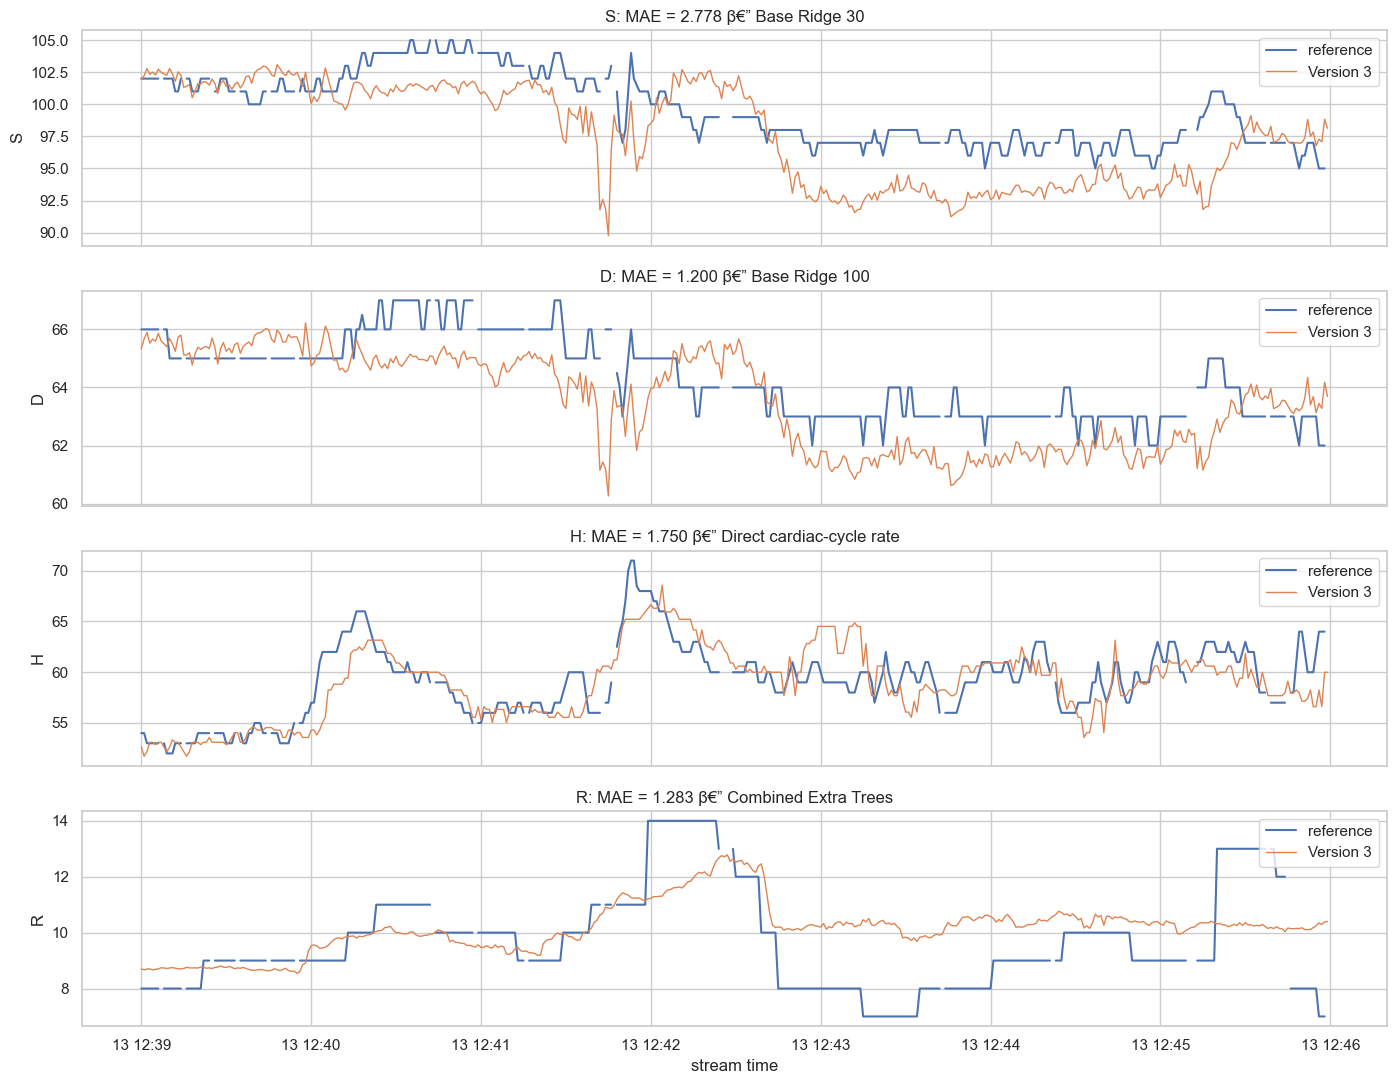

In [11]:
fig, axes = plt.subplots(4, 1, figsize=(14, 11), sharex=True)
for axis, target in zip(axes, TARGETS):
    axis.plot(stream_targets.index, stream_targets[target], label="reference", linewidth=1.5)
    axis.plot(predictions.index, predictions[target], label="Version 3", linewidth=1)
    axis.set(
        ylabel=target,
        title=f"{target}: MAE = {test_mae[target]:.3f} β€” {selected_by_target[target]}",
    )
    axis.legend(loc="upper right")
axes[-1].set_xlabel("stream time")
plt.tight_layout();

In [12]:
comparison = pd.DataFrame(
    {
        "version": ["Version 2", "Version 3"],
        "sum MAE": [10.260, test_mae.sum()],
        "score": [89.740, test_score],
        "explicit cardiac cycles": ["partial", "yes"],
        "clock predictors": ["no", "no"],
        "temporal model selection": ["yes", "yes"],
    }
)
display(comparison.round(3))
print(f"Version 3 change versus Version 2: {test_score - 89.740:+.3f} points")

,version,sum MAE,score,explicit cardiac cycles,clock predictors,temporal model selection
0,Version 2,10.260,89.740,partial,no,yes
1,Version 3,7.011,92.989,yes,no,yes


Version 3 change versus Version 2: +3.249 points


## 7. Conclusions and limits

Version 3 tests the hypothesis that explicit cardiac cycles add information beyond generic spectral and rolling features. Its strongest scientific contribution is the separation of cycle timing from phase-normalized morphology and the use of a direct inter-beat estimator when training-only validation supports it.

This remains a one-record experiment, not clinical validation. Cycle anchors are envelope landmarks rather than confirmed ECG R-peaks or manually annotated AO/AC events. The first and second halves of the normalized cycle are only systolic/diastolic proxies. Definitive event timing requires synchronized ECG and expert or imaging-based reference annotations. Generalizable blood-pressure modeling also requires multiple subjects, sessions, postures, and calibration states evaluated with subject/session-held-out validation.